In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.cluster import KMeans
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
import statsmodels.api as sm
from sklearn.metrics import accuracy_score

1.	Đọc File với các file trong thư mục dữ liệu. Hiển thị toàn bộ dữ liệu của file dữ liệu đã đọc. Tìm hiểu và giải thích về bộ dữ liệu. 

In [56]:
df = pd.read_csv('health_data.csv')
df.head()
#Dữ liệu có 6 cột và cột Habits và Obese là biến định tính

,Age,Height_cm,Weight_kg,BMI,Habits,Obese
0,65,159.7,102.7,40.28,FastFood,1
1,22,153.8,57.5,24.33,Vegetables,0
2,43,152.6,78.0,33.52,NoExercise,1
3,21,159.9,64.5,25.24,"FastFood,RegularCheckup",1
4,37,162.3,81.8,31.06,"FastFood,Vegetables",1


In [57]:
df.shape
#Dữ liệu có 300 dòng và 6 cột

(300, 6)

In [58]:
df.dtypes
#Dữ liệu có 5 cột kiểu số
# Age            int64
# Height_cm    float64
# Weight_kg    float64
# BMI          float64
# Obese          int64
# 1 cột kiểu text
# Habits        object

Age            int64
Height_cm    float64
Weight_kg    float64
BMI          float64
Habits        object
Obese          int64
dtype: object

In [59]:
df.info()
#Không có giá trị null trên tập dữ liệu -> vì tất cả là non-null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        300 non-null    int64  
 1   Height_cm  300 non-null    float64
 2   Weight_kg  300 non-null    float64
 3   BMI        300 non-null    float64
 4   Habits     300 non-null    object 
 5   Obese      300 non-null    int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 14.2+ KB


2.	Dự đoán chỉ số BMI (béo phì) dựa trên tuổi, cân nặng, chiều cao bằng hồi quy tuyến tính đơn biến và đa biến theo các phương pháp: 
a.	Linear Regression đơn giản 

2.1. Linear Regression đơn giản (đơn biến: Weight → BMI) 

In [60]:
X = df[['Weight_kg']]
y = df['BMI']
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
#Chi dữ liệu train test với target là BMI.
#Dữ liệu chia thày 70 train 30 test

In [61]:
lr_uni = LinearRegression().fit(X_train,y_train)
#Dữ liệu học với tập train

In [62]:
y_pred_1 = lr_uni.predict([[20]])
y_pred_1
# cân nặng 20 được dự đoán BMI là 7.2

/opt/homebrew/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([7.26994557])

In [63]:
y_pred = lr_uni.predict(X_test)
#Dự đoán mẫu dựa trên model đã học bằng tập test
y_pred 

array([29.82964081, 27.59676995, 22.39957053, 20.82116182, 16.31692233,
       22.51506385, 25.32540131, 21.36013065, 29.05968534, 25.74887682,
       29.21367643, 28.05874323, 19.9742108 , 25.71037905, 29.75264526,
       28.55921428, 14.89250471, 27.55827217, 26.3648412 , 34.71885803,
       19.12725979, 30.06062745, 23.97797924, 31.36955174, 25.47939241,
       24.01647702, 27.13479666, 23.47750819, 24.9019258 , 22.63055717,
       28.32822764, 33.024956  , 31.25405842, 27.09629889, 23.01553491,
       22.66905495, 10.38826522, 21.05214846, 24.63244139, 25.09441467,
       19.66622862, 20.35918854, 26.01836123, 29.29067198, 24.59394362,
       29.4061653 , 26.7883167 , 27.75076104, 21.70661061, 26.9423078 ,
       31.1385651 , 23.32351709, 20.62867295, 19.01176647, 27.36578331,
       15.7779535 , 24.67093916, 27.5197744 , 29.9836319 , 21.70661061,
       25.6333835 , 15.70095795, 32.63997827, 28.75170315, 30.09912522,
       22.93853936, 30.7150896 , 28.6747076 , 19.08876201, 18.85

In [64]:
print('---Đánh giá chỉ số với Hồi quy tuyến tính đơn biến ---')
print('MAS: ',mean_absolute_error(y_test,y_pred))
print('MSE: ',mean_squared_error(y_test,y_pred))
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2: ',r2_score(y_test,y_pred))
print("""
    MAS có giá trị 2.2 trong khoảng 2-4 mô hình dự đoán khá tốt cụ thể cho thấy mô hình dự đoán sai lệch khoảng 2.2 đơn vị so với giá trị thực tế.
    MSE:  8.4 là một con số nhỏ với biến mục tiêu BMI cho thấy mô hình dự đoán tốt, mức độ sai lệch ít
    RMSE:  2.9 gần hơn với MAS vì cùng đơn vị với biến mục tiêu, RMSE ở trong khoảng chấp nhận được -> mô hình ít sai lệch
    R2:  0.73 cho thấy 73 phần trăm biến thiên với biến phụ thuộc, còn 27 phần trăm chưa giải thích được bởi biến độc lập hiện tại.
      """)

---Đánh giá chỉ số với Hồi quy tuyến tính đơn biến ---
MAS:  2.299863572713744
MSE:  8.435107240238525
RMSE:  2.904325608508544
R2:  0.733382778173127

    MAS có giá trị 2.2 trong khoảng 2-4 mô hình dự đoán khá tốt cụ thể cho thấy mô hình dự đoán sai lệch khoảng 2.2 đơn vị so với giá trị thực tế.
    MSE:  8.4 là một con số nhỏ với biến mục tiêu BMI cho thấy mô hình dự đoán tốt, mức độ sai lệch ít
    RMSE:  2.9 gần hơn với MAS vì cùng đơn vị với biến mục tiêu, RMSE ở trong khoảng chấp nhận được -> mô hình ít sai lệch
    R2:  0.73 cho thấy 73 phần trăm biến thiên với biến phụ thuộc, còn 27 phần trăm chưa giải thích được bởi biến độc lập hiện tại.
      


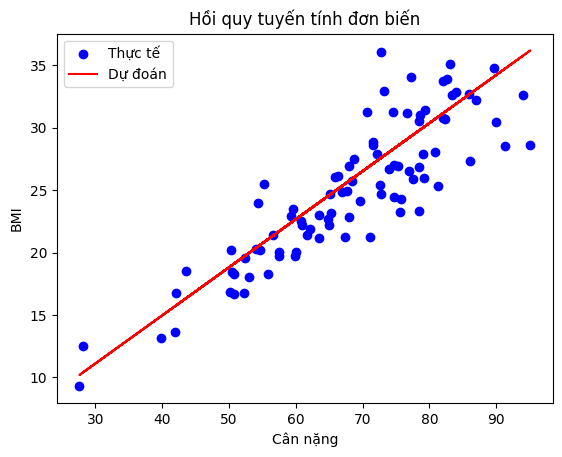

In [65]:
plt.scatter(X_test,y_test,color='blue',label = 'Thực tế')
plt.plot(X_test,y_pred,color = 'red',label = 'Dự đoán')
plt.xlabel('Cân nặng')
plt.ylabel('BMI')
plt.title('Hồi quy tuyến tính đơn biến')
plt.legend()
# Biểu độ scatter thể hiện giá trị có mối tương quan thuận. Cụ thể nếu biến thực tế tăng thì biến dự đoán cũng tăng
# Cho thấy model dự đoán tốt

2.2. Linear Regression đơn giản (đa biến (Age, Weight, Height → BMI)) 

In [66]:
X = df[['Age', 'Weight_kg', 'Height_cm']]
y = df['BMI']
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
#Chia dữ liệu train test với target là BMI.
#Dữ liệu chia thày 70 train 30 test

In [67]:
lr_multi = LinearRegression().fit(X_train, y_train)
#Mô hình được học với dữ liệu train 70%

In [68]:
y_pred = lr_multi.predict(X_test)
#Dự đoán dữ liệu trên tập test đã chia 30%
y_pred

array([31.3476631 , 24.9787119 , 23.35032843, 26.17676726, 19.81640228,
       23.83981484, 25.26165607, 21.75395419, 31.22493121, 27.30751793,
       26.81625177, 26.88974625, 17.38952615, 22.56237891, 27.18042229,
       27.20900793, 11.40491159, 34.6469061 , 24.12555565, 29.65609619,
       18.01540767, 26.18603664, 20.94882686, 33.63779038, 20.67126307,
       23.02615677, 28.91031427, 21.90395712, 26.32789285, 18.81230803,
       24.64384014, 32.58985401, 31.07292602, 28.73178137, 22.23309968,
       19.29317773, 14.92636238, 17.41937099, 24.87949376, 26.47397165,
       15.13545351, 20.46069051, 27.62225897, 33.57683137, 22.03391012,
       26.3312355 , 31.10422697, 32.5926501 , 19.53088445, 20.65032823,
       33.54731535, 21.31478238, 20.18493696, 18.19841582, 28.08351367,
       17.30394087, 23.16002866, 25.53656535, 28.54133485, 19.18714815,
       25.35048258, 11.77635373, 33.14635208, 24.19216302, 31.48935779,
       22.49846174, 28.40790811, 23.09204612, 15.22817877, 15.78

In [69]:
y_pred_1 = lr_multi.predict([[20,80,170]])
y_pred_1
# 'Age', 'Weight_kg', 'Height_cm' lần lượt là 20,80,170 được dự đoán BMI là 28.009

/opt/homebrew/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([28.00928103])

In [70]:
print('---Đánh giá chỉ số với Hồi quy tuyến tính đa biến ---')
print('MAS: ',mean_absolute_error(y_test,y_pred))
print('MSE: ',mean_squared_error(y_test,y_pred))
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2: ',r2_score(y_test,y_pred))
print("""
    MAE có giá trị 0.47 trong khoảng <2 mô hình dự đoán sai số rất thấp cụ thể cho thấy mô hình dự đoán sai lệch khoảng 0.47 đơn vị so với giá trị thực tế.
    MSE:  0.46 là một con số nhỏ với biến mục tiêu BMI cho thấy mô hình dự đoán tốt, mức độ sai lệch ít
    RMSE:  0.68 gần hơn với MAS vì cùng đơn vị với biến mục tiêu, RMSE ở trong khoảng rất thấp cho thấy mô hình rất tốt
    R2:  0.98 gần như tuyệt đối cho thấy 98.5 phần trăm sự biến thiên (variance) của biến mục tiêu (BMI) được giải thích bởi các biến độc lập (Age, Weight, Height)
      """)

---Đánh giá chỉ số với Hồi quy tuyến tính đa biến ---
MAS:  0.4743202736079559
MSE:  0.46653949974148856
RMSE:  0.6830369680635804
R2:  0.9852536000135006

    MAE có giá trị 0.47 trong khoảng <2 mô hình dự đoán sai số rất thấp cụ thể cho thấy mô hình dự đoán sai lệch khoảng 0.47 đơn vị so với giá trị thực tế.
    MSE:  0.46 là một con số nhỏ với biến mục tiêu BMI cho thấy mô hình dự đoán tốt, mức độ sai lệch ít
    RMSE:  0.68 gần hơn với MAS vì cùng đơn vị với biến mục tiêu, RMSE ở trong khoảng rất thấp cho thấy mô hình rất tốt
    R2:  0.98 gần như tuyệt đối cho thấy 98.5 phần trăm sự biến thiên (variance) của biến mục tiêu (BMI) được giải thích bởi các biến độc lập (Age, Weight, Height)
      


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


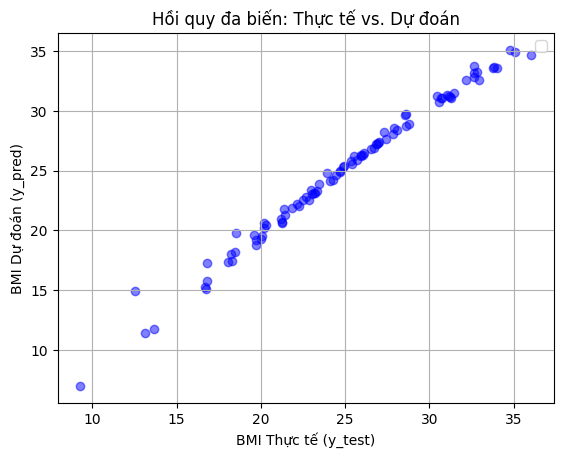

In [71]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.xlabel('BMI Thực tế (y_test)')
plt.ylabel('BMI Dự đoán (y_pred)')
plt.title('Hồi quy đa biến: Thực tế vs. Dự đoán')
plt.grid(True)
plt.legend()
# Biểu độ scatter thể hiện giá trị có mối tương quan thuận. Cụ thể nếu biến thực tế tăng thì biến dự đoán cũng tăng
# Cho thấy model dự đoán tốt

2.3. OLS để kiểm tra hệ số và ý nghĩa thống kê

In [72]:
X_ols = sm.add_constant(X)
ols = sm.OLS(y,X_ols).fit()
print('\n--- OLS Summary ---')
print(ols.summary())
print("""
R-squared (0.985) 3 biến Age, Weight_kg, và Height_cm giải thích được 98.5% sự thay đổi của biến BMI. Đây là một con số rất cao, cho thấy mô hình bám sát (fit) với dữ liệu.
Prob (F-statistic) (3.72e-269) gần như bằng 0. Nó cho thấy rằng mô hình cả 3 biến kết hợp có ý nghĩa thống kê và không tốt hơn các mô hình khác vì chỉ số quá nhỏ.
So sánh với mức 0.05.
Age (P=0.036): Vì 0.036 < 0.05, biến Age có ý nghĩa thống kê.
Weight_kg (P=0.000): Vì 0.000 < 0.05, biến Weight có ý nghĩa thống kê cao.
Height_cm (P=0.000): Vì 0.000 < 0.05, biến Height có ý nghĩa thống kê cao.
""")


--- OLS Summary ---
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     6441.
Date:                Wed, 12 Nov 2025   Prob (F-statistic):          3.72e-269
Time:                        12:28:35   Log-Likelihood:                -356.20
No. Observations:                 300   AIC:                             720.4
Df Residuals:                     296   BIC:                             735.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         52.9210      0.81

3.	Dự đoán khả năng béo phì (BMI > 25) bằng Logistic Regression. Giải thích kết quả các chỉ số của Confusion Matrix và các chỉ số Accuracy, Precision, Recall, F1-score, ROC

In [73]:
df['Obese'] = (df['BMI'] > 25).astype(int)
#lấy giá trị Obese có BMI >25 để dự đoán
X = df[['Age', 'Weight_kg', 'Height_cm']]
y =  df['Obese']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#Chia dữ liệu 70 train 30 test

In [75]:
sc = StandardScaler()
# LogisticRegression phải scale vì nó sử dụng các phương pháp tối ưu hóa lặp đi lặp lại
# -> khi scale các biến độc lập có cùng thang đo -> chạy nhanh hơn nhiều và chính xác hơn

In [76]:
X_train_s, X_test_s = sc.fit_transform(X_train), sc.transform(X_test)
# áp dụng transform cho X_train và X_test

In [77]:
logr = LogisticRegression().fit(X_train_s, y_train)
#mô hình học trên tập dữ liệu train

In [78]:
logr.predict([[20,90,160]])
#mô hình dự đoán chính xác

array([1])

In [79]:
y_pred = logr.predict(X_test_s)

In [80]:
print('--- Logistic Regression ---')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, logr.predict_proba(X_test_s)[:,1]))
#predict_proba() trả về xác suất cho cả hai lớp
#ROC AUC là chỉ số đo lường khả năng phân biệt của mô hình ở mọi ngưỡng threesold.
# Nó cần biết "mức độ tự tin" (xác suất) để "trượt" qua tất cả các ngưỡng đó và vẽ nên đường cong ROC
print("""
    [[46  0] [[TN(True Negative) FP(False Positive)]
    [ 0 44]] [FN(False Negative) TP(True Positive)]]
      -> Ma trận này cho thấy mô hình chính xác tuyệt đối trên tập test, không có bất kỳ dự đoán sai nào.
    accuracy: 1.00  -> Trong tổng số 90 mẫu thử, mô hình đã dự đoán đúng cả 90 mẫu
    Precision (Độ chính xác)= 1.00 (cho cả lớp 0 và 1):Trong tất cả các trường hợp mô hình "phán" là "Béo phì" (TP+FP), nó đã phán đúng 100%.
    Recall (Độ phủ/Độ nhạy) = 1.0 Trong tất cả các trường hợp thực tế là "Béo phì" (TP+FN), mô hình đã tìm thấy (phát hiện) đúng 100%.
    F1-score = 1.00 tuyệt đối hoàn hảo
    ROC AUC = 1.0
      - AUC (Area Under Curve) đo lường khả năng phân biệt (distinguish) giữa hai lớp 0 và 1 của mô hình.
        + 1.0: Mô hình phân biệt hoàn hảo. Nếu bạn đưa cho nó 1 người "Béo phì" và 1 người "Không béo phì", nó luôn chắc chắn 100% ai là ai.
        + 0.7 - 0.9: Mô hình tốt đến rất tốt.
        + 0.5: Mô hình vô dụng (giống như tung đồng xu).
      -> Kết quả 1.0 khẳng định mô hình có khả năng phân tách hai lớp một cách tuyệt đối.
        """)

--- Logistic Regression ---
[[46  0]
 [ 0 44]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        44

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

ROC AUC: 1.0

    [[46  0] [[TN(True Negative) FP(False Positive)]
    [ 0 44]] [FN(False Negative) TP(True Positive)]]
      -> Ma trận này cho thấy mô hình chính xác tuyệt đối trên tập test, không có bất kỳ dự đoán sai nào.
    accuracy: 1.00  -> Trong tổng số 90 mẫu thử, mô hình đã dự đoán đúng cả 90 mẫu
    Precision (Độ chính xác)= 1.00 (cho cả lớp 0 và 1):Trong tất cả các trường hợp mô hình "phán" là "Béo phì" (TP+FP), nó đã phán đúng 100%.
    Recall (Độ phủ/Độ nhạy) = 1.0 Trong tất cả các trường hợp thực tế là "Béo phì" (TP+FN), mô hình đã tìm thấy (phát hiện) đúng 100%.
    F1-score = 1.00 tuyệt đối hoàn hảo
 


    Mô hình dự đoán ĐÚNG 46 người là "Không Béo phì" và 44 người béo phì
    Không có lỗi dự đoán nhầm



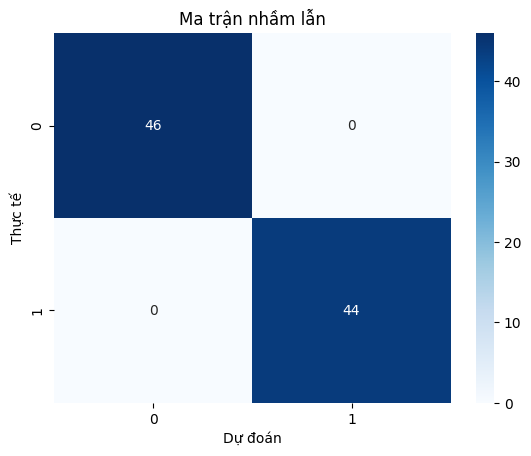

In [81]:
#sơ đồ heatmap
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d", cmap="Blues")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title("Ma trận nhầm lẫn")
print("""
    Mô hình dự đoán ĐÚNG 46 người là "Không Béo phì" và 44 người béo phì
    Không có lỗi dự đoán nhầm
""")

4.	Phân cụm người dùng bằng K-Means (3 nhóm sức khỏe). Giải thích kết quả, Vẽ biểu đồ Elbow để chọn k tối ưu.  Vẽ biểu đồ phân cụm có màu theo nhãn cụm. Kiểm thử với 1 mẫu dữ liệu cụ thể. Giải thích kết quả

In [82]:
X = df[['Age', 'Weight_kg', 'Height_cm']]
y = df['BMI']

In [83]:
scaler = StandardScaler()
#gọi hàm chuẩn hóa

In [84]:
X_scaler = scaler.fit_transform(X)
#chuẩn hóa dữ liệu train

In [85]:
km = KMeans(n_clusters=3, random_state=42)
#chia thành 3 cụm với random 42

In [86]:
df['Cluser'] = km.fit_predict(X_scaler)
#xem 3 cụm đã phân chia
df['Cluser']
cluster_map = {
    0: 'Sức khỏe tốt',
    1: 'Sức khỏe kém',
    2: 'Sức khỏe trung bình'
}
# Tạo một cột mới chứa tên đã đổi
df['Nhom_Suc_Khoe'] = df['Cluser'].map(cluster_map)
df['Nhom_Suc_Khoe']

/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


0             Sức khỏe tốt
1             Sức khỏe kém
2             Sức khỏe tốt
3             Sức khỏe kém
4             Sức khỏe kém
              ...         
295    Sức khỏe trung bình
296           Sức khỏe kém
297           Sức khỏe kém
298           Sức khỏe tốt
299    Sức khỏe trung bình
Name: Nhom_Suc_Khoe, Length: 300, dtype: object

/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of


    cần tìm điểm "khuỷu tay" (elbow) – điểm mà tại đó đường cong bị "gãy" rõ rệt nhất và bắt đầu trở nên thoải hơn (ít dốc hơn).
    Từ k=1 đến k=2: Đường dốc rất đứng. WCSS giảm mạnh (từ 900 xuống ~660). Điều này rất tốt.
    Từ k=2 đến k=3: Đường vẫn còn dốc, WCSS giảm đáng kể (từ ~660 xuống ~520).
    Từ k=3 đến k=4: Đường bắt đầu thoải ra. WCSS giảm (từ ~520 xuống ~420), nhưng không mạnh bằng trước. Đây chính là điểm "khuỷu tay" (Elbow).
    Từ k=4 trở đi: Đường ngày càng phẳng. Việc thêm nhiều cụm hơn (từ 4 lên 5, 6, 7...) chỉ giúp giảm WCSS rất ít.
    => Điểm k=3 là điểm cân bằng (trade-of) tốt nhất. Sau k=3, việc thêm một cụm mới không mang lại hiệu quả cao (WCSS giảm không đáng kể), 
    trong khi mô hình lại trở nên phức tạp hơn. Do đó, k=3 là lựa chọn tối ưu



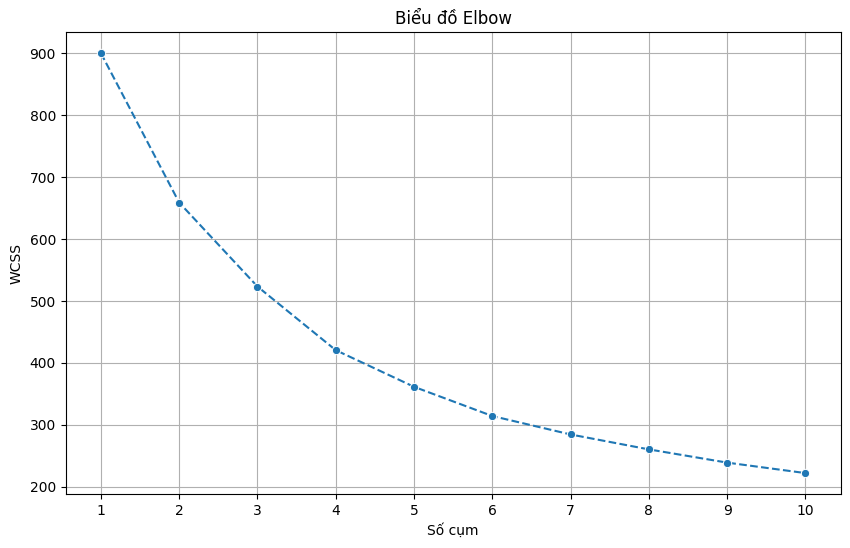

In [87]:
# Vẽ biểu đồ Elbow để chọn k tối ưu
wcss = []
k_range = range(1, 11)
# Dùng vòng lặp để tính WCSS ---
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X_scaler)
    wcss.append(km.inertia_)
# Vẽ bằng Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(x=k_range, y=wcss, marker='o', linestyle='--') 

# Seaborn dùng Matplotlib 
plt.title('Biểu đồ Elbow')
plt.xlabel('Số cụm')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
print("""
    cần tìm điểm "khuỷu tay" (elbow) – điểm mà tại đó đường cong bị "gãy" rõ rệt nhất và bắt đầu trở nên thoải hơn (ít dốc hơn).
    Từ k=1 đến k=2: Đường dốc rất đứng. WCSS giảm mạnh (từ 900 xuống ~660). Điều này rất tốt.
    Từ k=2 đến k=3: Đường vẫn còn dốc, WCSS giảm đáng kể (từ ~660 xuống ~520).
    Từ k=3 đến k=4: Đường bắt đầu thoải ra. WCSS giảm (từ ~520 xuống ~420), nhưng không mạnh bằng trước. Đây chính là điểm "khuỷu tay" (Elbow).
    Từ k=4 trở đi: Đường ngày càng phẳng. Việc thêm nhiều cụm hơn (từ 4 lên 5, 6, 7...) chỉ giúp giảm WCSS rất ít.
    => Điểm k=3 là điểm cân bằng (trade-of) tốt nhất. Sau k=3, việc thêm một cụm mới không mang lại hiệu quả cao (WCSS giảm không đáng kể), 
    trong khi mô hình lại trở nên phức tạp hơn. Do đó, k=3 là lựa chọn tối ưu
""")

In [88]:
df.head()

,Age,Height_cm,Weight_kg,BMI,Habits,Obese,Cluser,Nhom_Suc_Khoe
0,65,159.7,102.7,40.28,FastFood,1,0,Sức khỏe tốt
1,22,153.8,57.5,24.33,Vegetables,0,1,Sức khỏe kém
2,43,152.6,78.0,33.52,NoExercise,1,0,Sức khỏe tốt
3,21,159.9,64.5,25.24,"FastFood,RegularCheckup",1,1,Sức khỏe kém
4,37,162.3,81.8,31.06,"FastFood,Vegetables",1,1,Sức khỏe kém



    Biểu đồ phân cụm thấy có 3 cụm rõ rệt
      Cụm tím : nằm trong nhóm cân nặng cao nhất thường nằm trong khoảng cân nặng cao to và thừa cân nhất. Từ 60-100
      Cụm xanh: nằm trong nhóm cân nặng trung bình thường nằm trong khoảng 20-gần 100, nhóm tuổi trung niên
      Cụm Vàng: nằm trong nhóm cân nặng thấp thường trong khoảng 30-70, nhóm người cao tuổi từ 45-70 tuổi
    


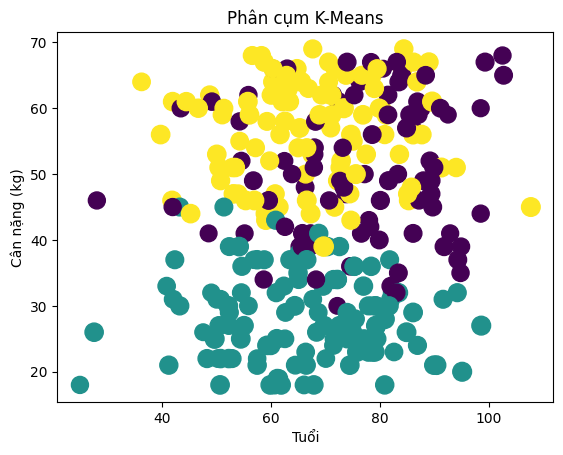

In [109]:
#  Vẽ biểu đồ phân cụm có màu theo nhãn cụm
plt.scatter(df['Weight_kg'],df['Age'],df['Height_cm'], c=df["Cluser"],cmap="viridis")
plt.xlabel("Tuổi")
plt.ylabel("Cân nặng (kg)")
plt.title("Phân cụm K-Means")
print("""
    Biểu đồ phân cụm thấy có 3 cụm rõ rệt
      Cụm tím : nằm trong nhóm cân nặng cao nhất thường nằm trong khoảng cân nặng cao to và thừa cân nhất. Từ 60-100
      Cụm xanh: nằm trong nhóm cân nặng trung bình thường nằm trong khoảng 20-gần 100, nhóm tuổi trung niên
      Cụm Vàng: nằm trong nhóm cân nặng thấp thường trong khoảng 30-70, nhóm người cao tuổi từ 45-70 tuổi
    """)

5.	Xây dựng 1 bài toán phân lớp (Classification) bằng thuật toán Navie Bayes (Gaussian Naive Bayes). Giải thích kết quả. Kiểm thử với 1 mẫu dữ liệu cụ thể.

In [90]:
# Xác định biến đặc trưng và biến mục tiêu
X = df[['Age', 'Weight_kg', 'Height_cm']]
y = df['Obese']

In [91]:
#chia tập dữ liệu train test 70-30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [92]:
#khởi tạo StandardScaler để chuẩn hóa biến
sc = StandardScaler() 

In [93]:
X_train_s = sc.fit_transform(X_train)
X_test_s = sc.transform(X_test)
# transform biến độc lập để các biến cùng cùng thang đo -> giúp mô hình dễ ra quyết định nhanh chóng

In [94]:
#gọi mô hình
gnb = GaussianNB()

In [95]:
# huấn luyện dựa trên tập train đã scale và biến mục tiêu
gnb.fit(X_train_s, y_train)

GaussianNB()

In [96]:
# dự đoán mô hình đã học với tập test
y_pred = gnb.predict(X_test_s) 
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1])

In [97]:
#dự đoán với 1 mẫu
y_pred_1 = sc.transform([[70,100,170]])
y_pred_1 = gnb.predict(y_pred_1)
y_pred_1

/opt/homebrew/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1])

In [98]:
#Đánh giá mô hình dựa vào Ma trận nhầm lẫn (Confusion Matrix):
print(confusion_matrix(y_test, y_pred))
# có 39 mẫu dự đoán đúng là có nguy cơ béo phì, 43 mẫu dự đoán đúng là không có nguy cơ béo phì
# 7 mẫu dự đoán sai

[[39  7]
 [ 1 43]]


In [116]:
y_test.head()

203    1
266    0
152    0
9      1
233    0
Name: Obese, dtype: int64

6.	Cây quyết định dự đoán nguy cơ béo phì. Vẽ biểu đồ biểu diễn cây quyết định đó. Giải thích các giá trị cho từng nút. Tính độ chính xác trên tập test. Kiểm thử với 1 mẫu dữ liệu cụ thể. Giải thích kết quả.

In [99]:
# lấy đặc trưng
X = df[['Age', 'Weight_kg', 'Height_cm']]
y = df['Obese']

In [100]:
# khởi tạo mô hình với độ sâu 3 và random 42
dt = DecisionTreeClassifier(max_depth=3, random_state=42)

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# chia dữ liệu tập train và test 70-30

In [102]:
dt.fit(X_train, y_train) #mô hình học trên dữ liệu train

DecisionTreeClassifier(max_depth=3, random_state=42)

In [103]:
#Mô hình dự đoán trên tập test
y_pred = dt.predict(X_test)

In [104]:
# Tính độ chính xác
accuracy = accuracy_score(y_test, y_pred)
accuracy
print("""
    Mô hình dự đoán gần như chính xác vì độ tinh cây lên tới 0.8. Tức là mô hình dự đoán 80% tổng số mẫu
    """)


    Mô hình dự đoán gần như chính xác vì độ tinh cây lên tới 0.8. Tức là mô hình dự đoán 80% tổng số mẫu
    


In [105]:
# In báo cáo chi tiết
classes = ['Khong Beo phi', 'Beo phi']
print("Báo cáo phân loại (Classification Report):")
print(classification_report(y_test, y_pred, target_names=classes))
print("""
    Phân tích lớp "Béo phì": 
      - Recall: 1.00. Trong số 44 người thực sự bị "Béo phì" trong tập test, mô hình đã phát hiện đúng 100% (44/44 người).
      - Precision: 0.81. Khi mô hình phán một người là "Béo phì", nó đúng 81% số lần.
    Phân tích lớp "Không Béo phì":
      - Recall: 0.78. Trong số 46 người thực sự "Không Béo phì", mô hình chỉ nhận diện đúng 78% (khoảng 36 người).
      - Precision: 1.00. Khi mô hình phán một người là "Không Béo phì", nó chắc chắn đúng 100%.
    """)

Báo cáo phân loại (Classification Report):
               precision    recall  f1-score   support

Khong Beo phi       1.00      0.78      0.88        46
      Beo phi       0.81      1.00      0.90        44

     accuracy                           0.89        90
    macro avg       0.91      0.89      0.89        90
 weighted avg       0.91      0.89      0.89        90


    Phân tích lớp "Béo phì": 
      - Recall: 1.00. Trong số 44 người thực sự bị "Béo phì" trong tập test, mô hình đã phát hiện đúng 100% (44/44 người).
      - Precision: 0.81. Khi mô hình phán một người là "Béo phì", nó đúng 81% số lần.
    Phân tích lớp "Không Béo phì":
      - Recall: 0.78. Trong số 46 người thực sự "Không Béo phì", mô hình chỉ nhận diện đúng 78% (khoảng 36 người).
      - Precision: 1.00. Khi mô hình phán một người là "Không Béo phì", nó chắc chắn đúng 100%.
    


In [106]:
# Độ quan trọng của các đặc trưng
importance = pd.Series(dt.feature_importances_,index=X.columns)
print("Độ quan trọng của các đặc trưng là: \n", importance.sort_values(ascending=False))

Độ quan trọng của các đặc trưng là: 
 Weight_kg    0.793100
Height_cm    0.201460
Age          0.005441
dtype: float64



    gini:   Độ “lẫn lộn” giữa các lớp (0 = sạch, 0.5 = hỗn tạp)
    Nút gốc: Mô hình dùng Weight_kg <= 62.45 làm điều kiện chính. Toàn bộ 210 mẫu trong tập train đều đi qua đây.
    - Nhánh bên trái (True - Nhẹ cân): Nếu Weight_kg <= 62.45 (đúng), mô hình đi sang trái.
        gini = 0.109 cho thấy nút sạch. Nhóm nhẹ cân này gần như chắc chắn là "Không Béo phì" (65 thắng 4).
    - Nhánh bên phải (False - Nặng cân): Nếu Weight_kg > 62.45 (sai), mô hình đi sang phải.
        gini = 0.31 cho thấy nút có mức độ nhầm lẫn trung bình. Nhóm nặng cân này có khả năng rất cao là "Béo phì" (114 thắng 27).
    ==> Tổng thể: Mô hình đã học được rằng Cân nặng là yếu tố quyết định chính. 
    Sau đó, nó dùng Height_cm và Age ở các tầng dưới để tinh chỉnh dự đoán cho các trường hợp phức tạp hơn.
    


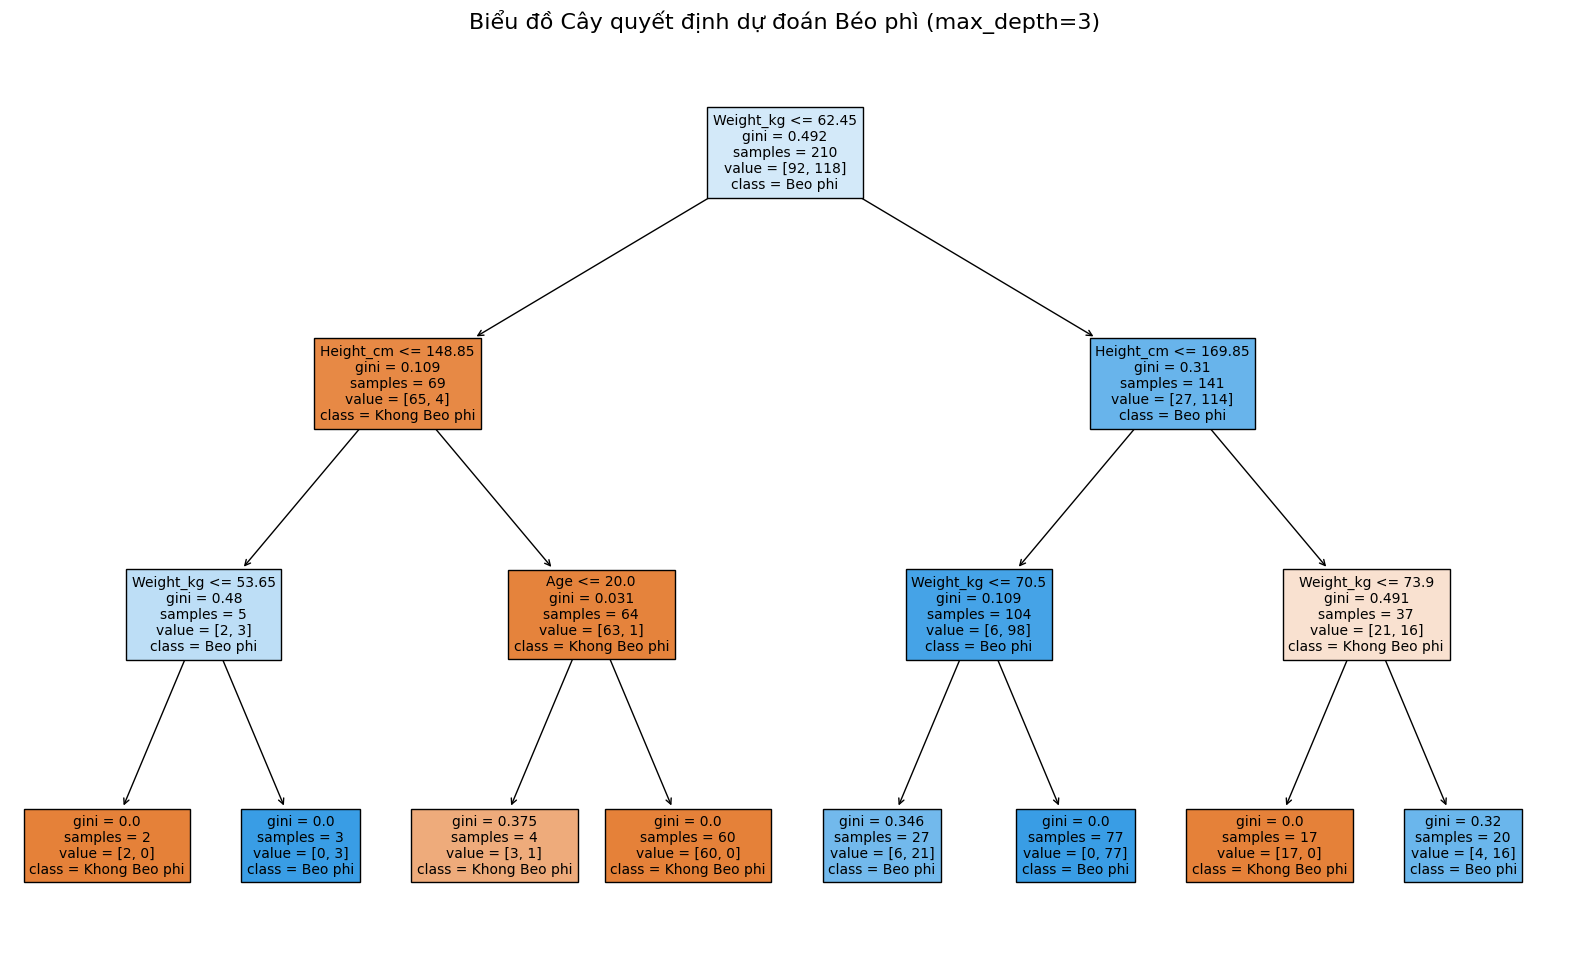

In [107]:
# Biểu đồ cây quyết định
classes = ['Khong Beo phi', 'Beo phi']
plt.figure(figsize=(20, 12))
plot_tree(
    dt,
    feature_names = X.columns,      # Tên các đặc trưng
    class_names=classes,         # Tên các lớp
    filled=True,                 # Tô màu cho các nút
    fontsize=10                  # Cỡ chữ
)
plt.title("Biểu đồ Cây quyết định dự đoán Béo phì (max_depth=3)", fontsize=16)
print("""
    gini:   Độ “lẫn lộn” giữa các lớp (0 = sạch, 0.5 = hỗn tạp)
    Nút gốc: Mô hình dùng Weight_kg <= 62.45 làm điều kiện chính. Toàn bộ 210 mẫu trong tập train đều đi qua đây.
    - Nhánh bên trái (True - Nhẹ cân): Nếu Weight_kg <= 62.45 (đúng), mô hình đi sang trái.
        gini = 0.109 cho thấy nút sạch. Nhóm nhẹ cân này gần như chắc chắn là "Không Béo phì" (65 thắng 4).
    - Nhánh bên phải (False - Nặng cân): Nếu Weight_kg > 62.45 (sai), mô hình đi sang phải.
        gini = 0.31 cho thấy nút có mức độ nhầm lẫn trung bình. Nhóm nặng cân này có khả năng rất cao là "Béo phì" (114 thắng 27).
    ==> Tổng thể: Mô hình đã học được rằng Cân nặng là yếu tố quyết định chính. 
    Sau đó, nó dùng Height_cm và Age ở các tầng dưới để tinh chỉnh dự đoán cho các trường hợp phức tạp hơn.
    """)

In [108]:
# Kiểm thử với 1 mẫu dữ liệu cụ thể 
prediction = dt.predict([[30, 80, 170]])
prediction
#với số liệu trên, kết luận béo phì

/opt/homebrew/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])